In [1]:
from cosipy import BinnedData, UnBinnedData#, COSILike
# from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response import FullDetectorResponse, PointSourceResponse, GalacticResponse
from cosipy.response.functions import get_integrated_spectral_model
from cosipy.ts_map import FastNormFit, FastTSMap
from cosipy import SourceInjector

# from COSILikeNew import COSILike

from scoords import SpacecraftFrame

import astropy.units as u
import astropy.constants as const
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler
from scipy.optimize import curve_fit, minimize
from scipy.signal import find_peaks
from scipy.special import gammaln
import pandas as pd
from lmfit import Model
from lmfit.models import GaussianModel

from threeML import Line, Gaussian, Cauchy, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter
from histpy import Histogram, Axes, Axis, HealpixAxis
from tqdm import tqdm
import mhealpy as hp

from pathlib import Path

import os

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['orange', 'limegreen', 'b', 'r']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

18:19:07 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=537088;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=834681;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=240829;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=106155;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=688578;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=253645;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=899485;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=368034;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

18:19:09 WARNING   No fermitools installed                                              ]8;id=725928;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=114164;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=809681;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=478034;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=86474;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=31779;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=229147;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=662298;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
import numba
numba.set_num_threads(1)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [3]:
DATA_DIR = Path('/Users/penguin/Documents/Research/COSI/COSIpy/docs/DC4/')

In [ ]:
psr_filename = DATA_DIR / 'data/responses/extended_source_response_Ti44_merged.h5'

### Background

#### Binned

In [6]:
# To extract binned data

bg = BinnedData("inputs.yaml")

In [7]:
bg.time_bins = 86400*93       # Specifies size of time bin to full 3 month width
bg_filename = DATA_DIR / f'data/backgrounds/binned/gal_DC4_bkg_Ti44_binned_smoothed_fwhm_10.0deg.hdf5'

bg.energy_bins

[1154.0, 1160.0]

In [8]:
bg.load_binned_data_from_hdf5(bg_filename)

#### TS Calculation

In [9]:
background_counts_model = bg.binned_data.project('Em','Phi','PsiChi').todense()
tau = 92.35 * 86400     # Exact exposure time in seconds
lambda_b = background_counts_model / tau
lambda_s = 0.

In [10]:
background_counts_model.contents.max()

5.548115891346962

In [11]:
def get_poisson_log_like(value, lam):
    value = np.asarray(value)
    return -lam + value * np.log(lam) - gammaln(value+1)

def get_poisson_like(value, lam, threshold=1e-6):
    log_p = get_poisson_log_like(value, lam)
    # Convert to probability
    p = np.exp(log_p)
    # Zero out small values
    p[p < threshold] = 0.0
    return p

In [12]:
get_poisson_like(np.arange(15), lam=5.).sum()      # Increase np.arange for even higher precision

0.9997737463238227

In [22]:
def get_SNR(n_sr, n_br):
    return (n_sr - n_br) / np.sqrt(n_sr + n_br)

def false_positive_prob_mc(lam_br, lam_sr, n_samples=100000):
    # Sample background counts
    n_br = np.random.poisson(lam=lam_br, size=n_samples)
    # Sample signal+background counts
    n_sr = np.random.poisson(lam=lam_sr, size=n_samples)
    
    # Define your false positive condition
    # Example: sr looks like signal but is actually background
    # false_pos = np.where(get_SNR(n_sr, n_br) > 3, 1, 0)  # SNR threshold set to 3
    false_pos = np.where(get_SNR(n_sr, n_br) > 3, 1, 0)  # SNR threshold set to 3

    return np.mean(false_pos)       # np.mean is not arbitrary — it’s the Monte Carlo estimator 
                                    # of the probability I need. It replaces the explicit sum/
                                    # integral I was doing with the grid.

In [23]:
false_positive_prob_mc(300, 300+0, n_samples=1000000)

0.001327

In [ ]:
F = 1e-6 * u.ph / u.cm / u.cm / u.s     # Flux value is not used by the TS map code
mu = 1157.02 * u.keV
sigma = 19.25 * u.keV             # 5000 km/s

spectrum = Gaussian()
spectrum.F.value = F.value
spectrum.F.unit = F.unit
spectrum.mu.value = mu.value 
spectrum.mu.unit = mu.unit
spectrum.sigma.value = sigma.value
spectrum.sigma.unit = sigma.unit

In [25]:
loc_br = tau * lambda_b
loc_sr = lambda lambda_s: tau * (lambda_s + lambda_b)

In [26]:
n_samples = 1000

# flat = loc_br.contents.ravel()  # flatten lam
# # generate samples for each element in lam
# samples = np.random.poisson(flat, size=(n_samples, flat.size))
# # reshape back to (n_samples, *lam.shape)
# n_br = samples.reshape((n_samples, *loc_br.shape))

flat = loc_sr(0).contents.ravel()  # flatten lam
# generate samples for each element in lam
samples = np.random.poisson(flat, size=(n_samples, flat.size))
# reshape back to (n_samples, *lam.shape)
n_sr = samples.reshape((n_samples, *loc_sr(0).shape))

In [20]:
# counts = psr.get_counts(1816)

# # counts = np.sum(counts, axis=psr.axes.label_to_index("Em") - 1, dtype=psr.dtype)

# # counts = counts.reshape(counts.shape[0], -1)

# # psr_sum = np.sum(counts, axis=1)
# # valid_cells = np.where(np.logical_and(data_cds_array > 0,
# #                                         bkg_model_cds_array > 0))[0]
# # psr = counts[:, self.valid_cells]

# flux = get_integrated_spectral_model(spectrum, psr.axes["Ei"])
# ei_weights = flux.contents.value

# # ei_sum = np.dot(psr_sum, ei_weights)
# ei_sum = np.sum(counts)*ei_weights[0]
# ei_cds_array = np.tensordot(counts, ei_weights, axes=(0,0))

In [21]:
# # Instantiate the solver
# fnf = FastNormFit()

# # Assume you already prepared these arrays externally:
# # data_cds_array : np.ndarray of observed counts
# # bkg_model_cds_array : np.ndarray of background model counts
# # ei_cds_array : np.ndarray of unit excess counts (per norm=1)
# # ei_sum : float, sum of unit excess over all CDS cells

# # Perform the solve call directly
# result = fnf.solve(n_sr[0].ravel(),
#                    loc_br.contents.ravel(),
#                    ei_cds_array.ravel(),
#                    ei_sum)

# # result is typically [ts value, norm, norm_err, failed, # iterations]
# print(result)

### False Positive

In [22]:
ts_results = np.zeros((n_samples, 3072))

In [23]:
# Create a FastTSMap object. Will fit the TS map in the following cells.
for i in range(0,2):
    data = Histogram(bg.binned_data.project('Em', 'Phi', 'PsiChi').axes, n_sr[i], sparse=False)

    ts = FastTSMap(
                data = data, 
                bkg_model = loc_br, 
                orientation = None, 
                response_path = psr_filename, 
                cds_frame = "galactic",
                )
    
    energy_channel=[0, 1]

    data_cds_array, bkg_model_cds_array, psr_cache = \
        ts._prepare_inputs(energy_channel, spectrum, max_cache_size=None)

    hyp_frame = "galactic"

    hypothesis_coords = ts._get_hypothesis_coords(nside=16, coordsys=hyp_frame)

    results = [
        ts._fit_one_direction(source,
                                data_cds_array,
                                bkg_model_cds_array,
                                psr_cache)
        for source in hypothesis_coords
    ]
    ts_results[i] = np.array([result[0] for result in results])

In [ ]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=None)

In [27]:
ts_results[0]

array([0.        , 0.        , 0.00859006, ..., 0.09781473, 0.15719025,
       0.44615992])

In [ ]:
raise

RuntimeError: No active exception to reraise

In [ ]:
results[np.argsort(ts_results)[-1]]

(5.505458779558012, 13.36441449293224, 5.785686080939053, False, 2)

In [ ]:
np.mean(mask)

6.510416666666666e-07

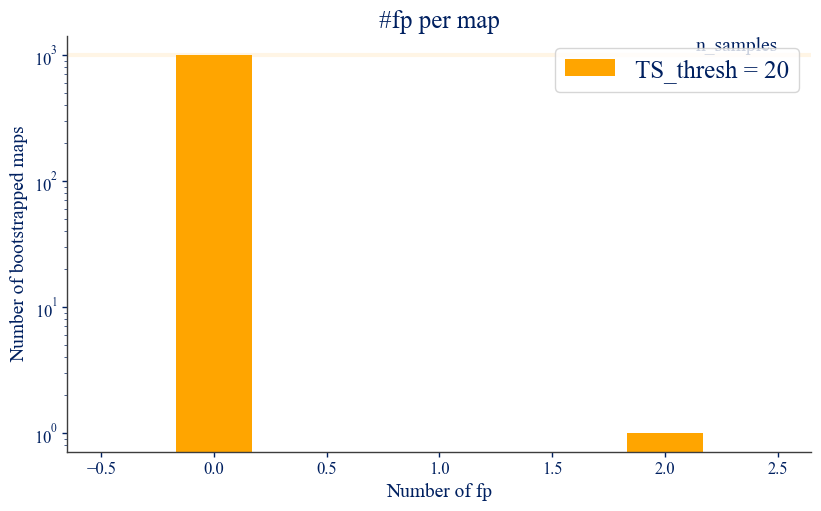

In [ ]:
TS_threshold = 20                # 20 = 4.5^2
mask = np.where(ts_results > TS_threshold, 1, 0)

plt.hist(np.sum(mask, axis=1), bins=np.linspace(-0.5, 2.5, 10), label=f'TS_thresh = {TS_threshold}')
plt.axhline(1000, alpha=0.1)
plt.annotate('n_samples', (2.5, 1000), ha='right', va='bottom', fontsize=14)
plt.yscale('log')
plt.xlabel('Number of fp')
plt.ylabel('Number of bootstrapped maps')
plt.title('#fp per map', fontsize=18)
plt.legend(loc='upper right', fontsize=18)
plt.show()

Interpretation: 95% of the times, the map containing 3072 pixels does not contain any false positives. 5% of the times, it may/can contain a/many false positive(s). (This interpretation is based on the xkcd jelly bean comic wherein the jelly bean colors are akin to the pixels - the 95% confidence threshold is adapted / Sidak-corrected to repeatedly perform the test for different colors / pixels - and the total sample space is all jelly beans / 1 single map.)
By creating 1000 such maps, I am essentially estimating the false positive percentages 95 and 5. 

In [ ]:
np.mean(np.any(mask, axis=1))

0.035

In [2]:
ts_results = np.load('ts_results.npy')

In [4]:
np.sum(np.sum(mask, axis=1) > 0)

35

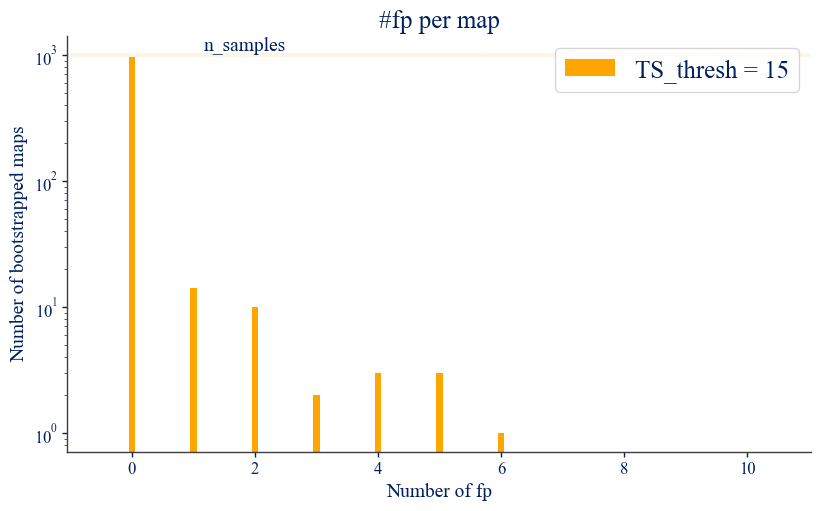

In [3]:
TS_threshold = 15
mask = np.where(ts_results > TS_threshold, 1, 0)

plt.hist(np.sum(mask, axis=1), bins=np.linspace(-0.5, 10.5, 100), label=f'TS_thresh = {TS_threshold}')
plt.axhline(1000, alpha=0.1)
plt.annotate('n_samples', (2.5, 1000), ha='right', va='bottom', fontsize=14)
plt.yscale('log')
plt.xlabel('Number of fp')
plt.ylabel('Number of bootstrapped maps')
plt.title('#fp per map', fontsize=18)
plt.legend(loc='upper right', fontsize=18)
plt.show()

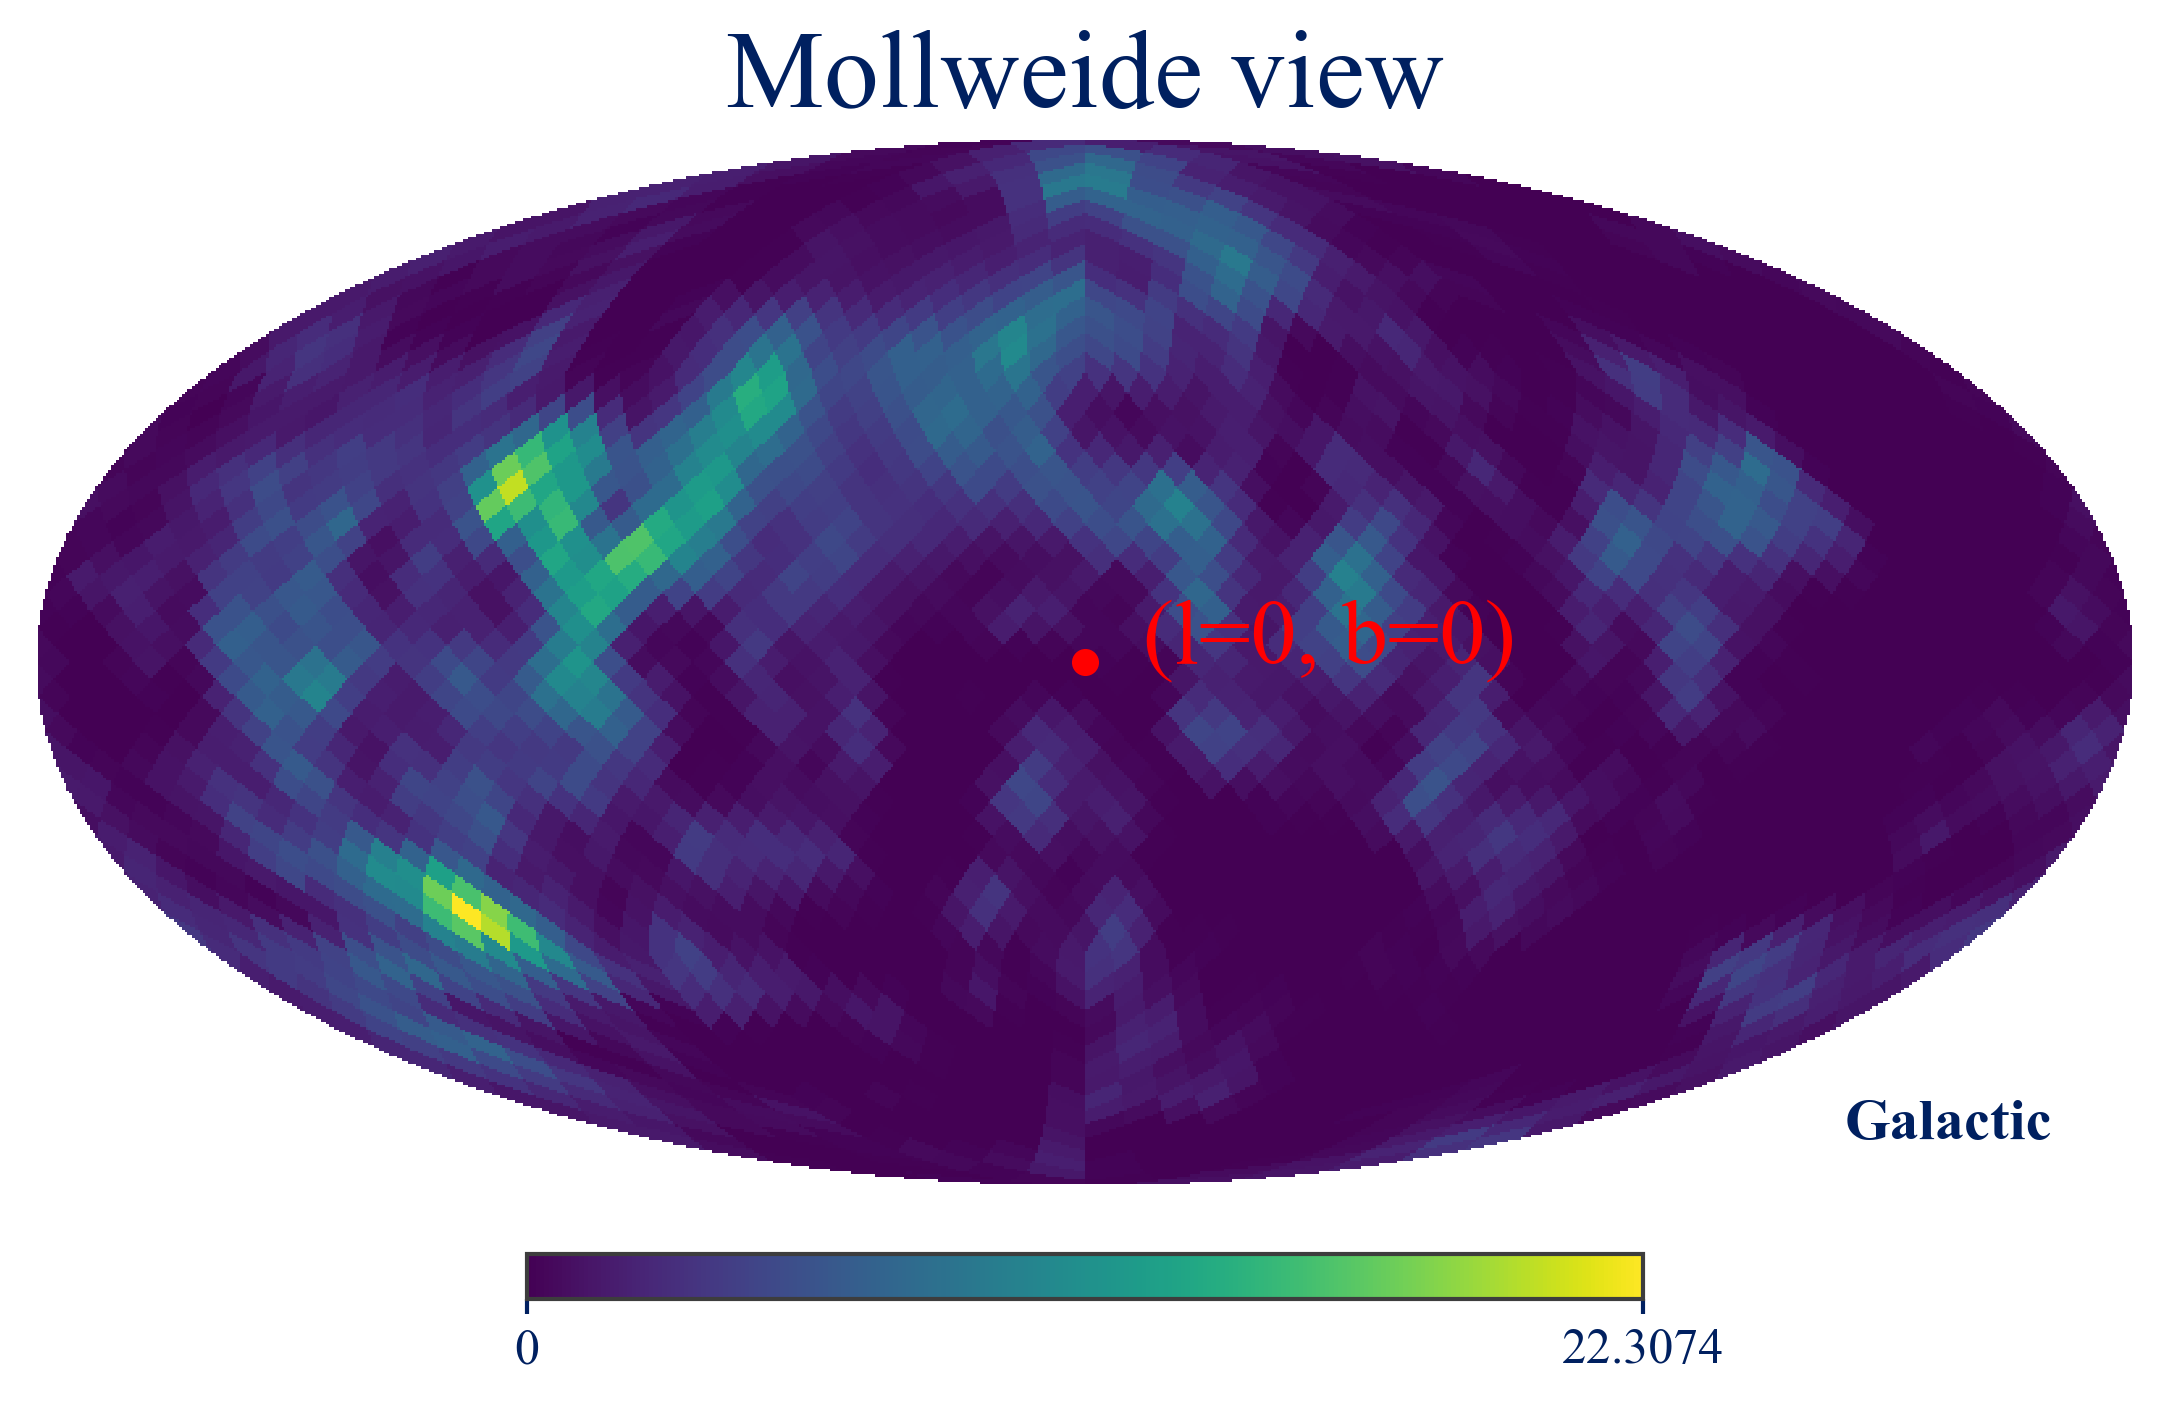

In [ ]:
ts.plot_ts(ts_results[101], skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)
# ts.plot_ts(np.where(ts_results[101] > 20, 1, 0), skycoord = None, containment = None, scheme="nested",
#             save_plot = False, dpi = 300)

### Source Injector - False Negative

In [27]:
def spectrum_reset(spec, F=None, mu=None, sigma=None):
    spec.F.value = F.value
    spec.F.unit = F.unit
    spec.mu.value = mu.value 
    spec.mu.unit = mu.unit
    spec.sigma.value = sigma.value
    spec.sigma.unit = sigma.unit
    return spec

def simulate_point_sources(spec, rsp_path, src, mu=1157.02, sig=3.85):
    # point_sources expected format
    ## list of tuples
    ## tuple[0] = Source Name
    ## tuple[1] = l in deg
    ## tuple[2] = b in deg
    ## tuple[3] = flux only scalar value
    injector = SourceInjector(response_path = rsp_path, response_frame = 'galactic')

    mu = mu * u.keV
    sigma = sig * u.keV

    # Define the coordinate of the point source
    source_coord = SkyCoord(l = src[1], b = src[2], frame = "galactic", unit = "deg")

    # define the point source
    F = src[3] / u.cm / u.cm / u.s
    spectrum = spectrum_reset(spec, F=F, mu=mu, sigma=sigma)
    point_source = PointSource(src[0], l = source_coord.l.deg, b = source_coord.b.deg, spectral_shape=spectrum)

    # define the model. The model can contain multiple point sources.
    model = Model(point_source)

    # Get the data of the injected source
    model_injected = injector.inject_model(model = model, make_spectrum_plot = False, data_save_path = None)

    return model_injected

In [ ]:
CasAsymmetric = 'CasAsymmetric', 111.734745, -2.129570, 3e-4        # 1000 km/s

SN1987A = 'SN1987A', 279.7, -31.9, 7e-6
Tycho = 'Tycho', 120.1, +1.4, 16e-6
Kepler = 'Kepler', 4.5, +6.8, 10e-6 
VelaJr = 'VelaJr', 266.3, -1.2, 28e-6
G1903 = 'G1903', 1.9, +0.3, 10e-6

STS1 = 'STS1', 80.2, +0.8, 1e-6
STS2 = 'STS2', 81.2, +0.9, 2e-6
STS3 = 'STS3', 84.0, -1.3, 1e-6
STS4 = 'STS4', 283.8, +75.5, 2e-6
STS5 = 'STS5', 184.6, -5.8, 1e-6
STS6 = 'STS6', 266.3, -49.7, 1e-6

known_SNRs = [SN1987A, Tycho, Kepler, VelaJr, G1903]
STS_SNRs = [STS1, STS2, STS3, STS4, STS5, STS6]

In [28]:
def calc_ts_values(injected_flux, sigma, ipix, niters=300):
    nside = 16

    # Sensitivity varies by assumed spectral shape and broadening (sigma), 
    # response or analysis width (1154-1160), and ipix
    lonlat = hp.pix2ang(nside, ipix, nest=True, lonlat=True)
    src = ('Source',) + (lonlat) + (injected_flux,)

    # Injected model is fairly (but not perfectly) deterministic
    model_injected = simulate_point_sources(Gaussian(), psr_filename, src, sig=sigma, mu=1157.02)

    # Create a FastTSMap object. Will fit the TS map at one particular pixel.
    ts_at_ipix = np.zeros(niters)
    for i in range(niters):
        data = Histogram(bg.binned_data.project('Em', 'Phi', 'PsiChi').axes, n_sr[i], sparse=False)

        ts = FastTSMap(
                    data = data + model_injected, 
                    bkg_model = loc_br, 
                    orientation = None, 
                    response_path = psr_filename, 
                    cds_frame = "galactic",
                    )
        
        energy_channel = [0, 1]

        data_cds_array, bkg_model_cds_array, psr_cache = \
            ts._prepare_inputs(energy_channel, spectrum, max_cache_size=None)

        hyp_frame = "galactic"

        hypothesis_coords = ts._get_hypothesis_coords(nside=nside, pixels=ipix, coordsys=hyp_frame)

        results = [
            ts._fit_one_direction(source,
                                    data_cds_array,
                                    bkg_model_cds_array,
                                    psr_cache)
            for source in hypothesis_coords
        ]
        ts_at_ipix[i] = results[0][0]

    return ts_at_ipix

In [29]:
def calc_flux_limit(flux_range, flux_inc=5e-6, sigma=19.25, ipix=0, niters=300, percentile=0.05, TS_threshold = 15):
    if flux_range[0] > flux_range[1]:
        raise

    flux = flux_range[0]
    while(1):

        ts_at_ipix = calc_ts_values(flux, sigma, ipix, niters)
        
        print(f'{flux:.2e}, {np.quantile(ts_at_ipix, q=percentile).round(2)}')
        if np.quantile(ts_at_ipix, q=percentile) > TS_threshold:
            print(f'Flux limit at {percentile}th percentile is {flux:.2e}')
            break

        flux += flux_inc
        if flux > flux_range[1]:
            print('\nFlux range is insufficient')
            break

    return ts_at_ipix

In [261]:
ts_at_ipix = calc_flux_limit([0.3e-4, 1e-4], sigma=3.85)

3.00e-05, 12.5
3.50e-05, 19.07
Flux limit at 0.05th percentile is 3.50e-05


In [27]:
3.5e-5*2.07 / (8)**0.5

2.561494314848268e-05

In [35]:
ts_at_ipix = calc_flux_limit([0.1e-4, 0.3e-4], sigma=3.85/5, percentile=0.5, flux_inc=0.000001)

1.00e-05, 7.32
1.10e-05, 9.44
1.20e-05, 10.07
1.30e-05, 16.99
Flux limit at 0.5th percentile is 1.30e-05


In [42]:
ts_at_ipix = calc_flux_limit([0.1e-4, 0.3e-4], sigma=3.85/5, percentile=0.5, flux_inc=0.000001, TS_threshold=9)

1.00e-05, 6.79
1.10e-05, 10.41
Flux limit at 0.5th percentile is 1.10e-05


In [43]:
1.1e-5 / 8**0.5

3.889087296526011e-06

In [ ]:
2.3e-5*2.83 / (8)**0.5

2.3012790193716188e-05

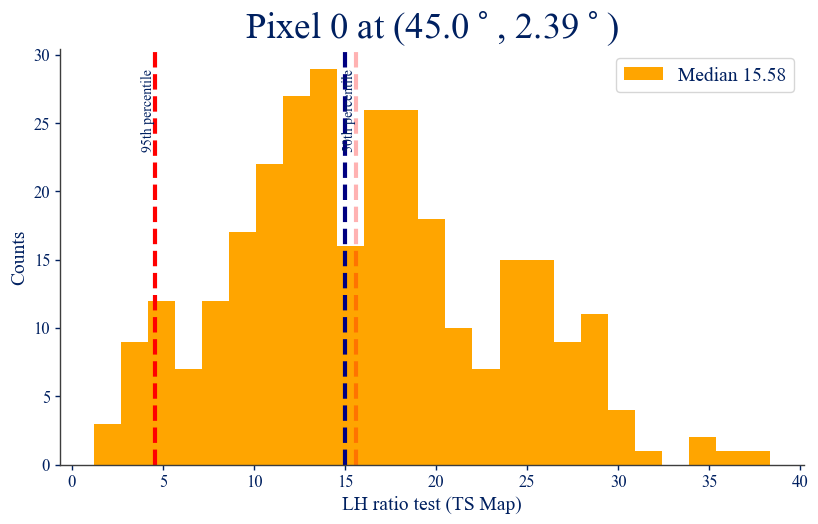

In [33]:
counts, _, _ = plt.hist(ts_at_ipix, label=f'Median {np.median(ts_at_ipix):.2f}')
plt.axvline(np.median(ts_at_ipix), color='r', ls='--', alpha=0.3)
plt.annotate('50th percentile', (np.median(ts_at_ipix), np.max(counts)), va='top', ha='right', rotation=90, fontsize=10)
plt.axvline(np.quantile(ts_at_ipix, 0.05), color='r', ls='--', alpha=1)
plt.annotate('95th percentile', (np.quantile(ts_at_ipix, 0.05), np.max(counts)), va='top', ha='right', rotation=90, fontsize=10, alpha=1)
plt.axvline(15, color='navy', ls='--', alpha=1)
plt.ylabel('Counts')
plt.xlabel('LH ratio test (TS Map)')
plt.legend(fontsize=14)

lonlat = hp.pix2ang(16, ipix, nest=True, lonlat=True)
plt.title(f'Pixel {ipix} at ({lonlat[0].round(2)}$^\circ$, {lonlat[1].round(2)}$^\circ$)')
plt.show()

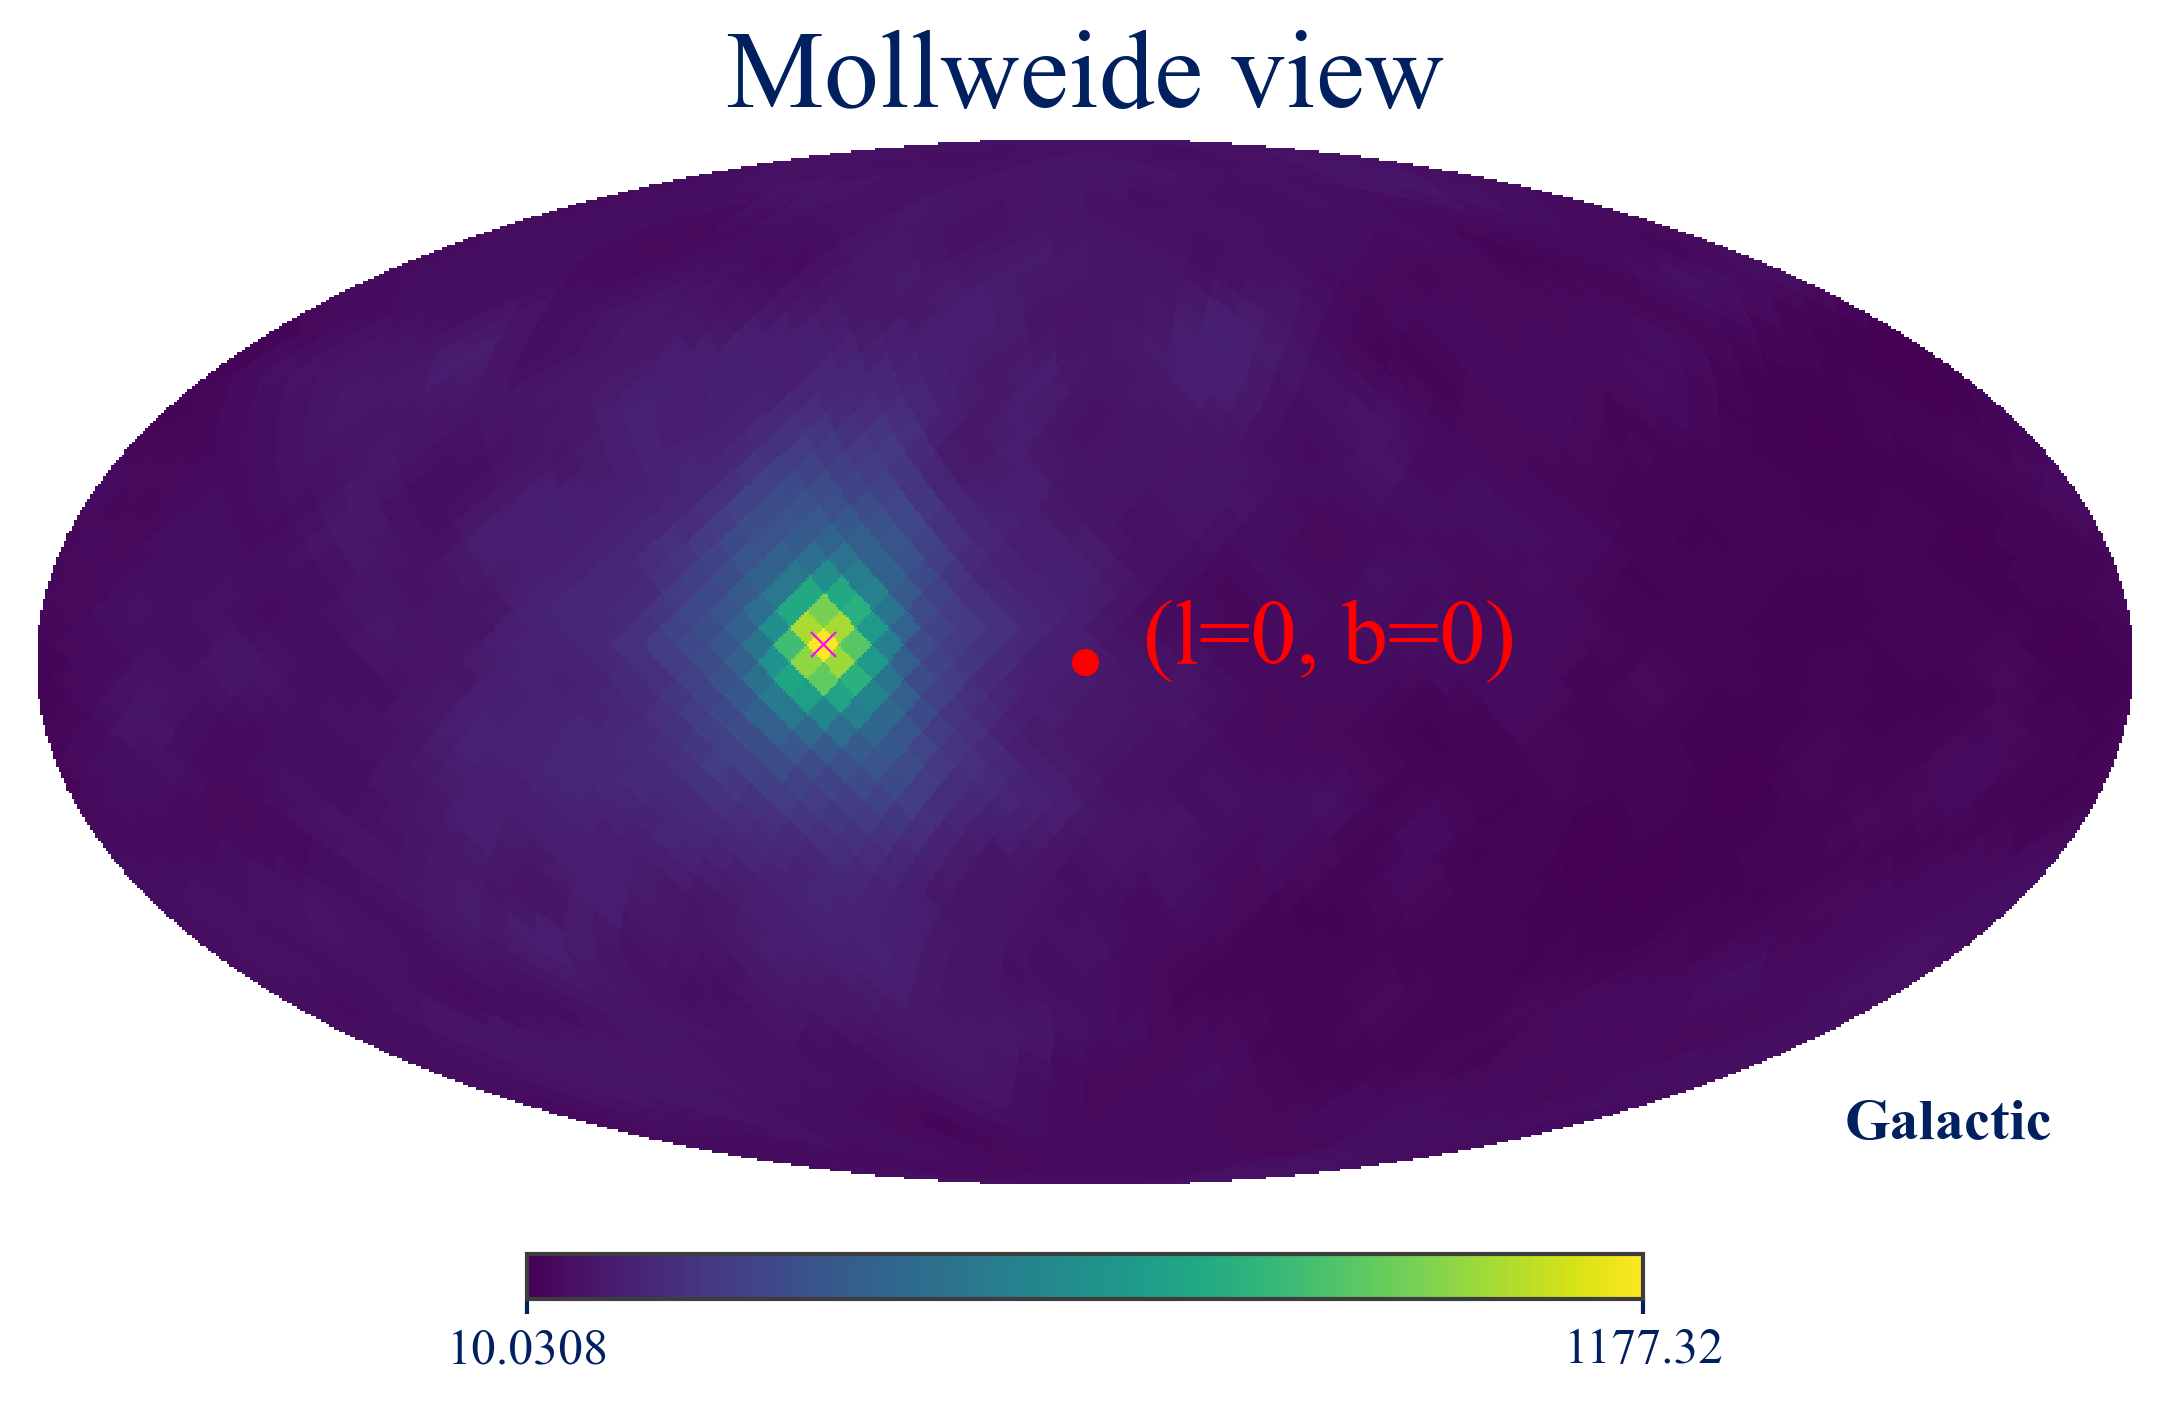

In [68]:
coord = np.deg2rad(lonlat) * u.rad
ts.plot_ts(ts_results[0], skycoord=SkyCoord(*coord, frame='galactic'))

In [ ]:
betas = []
for lambda_s in signal_strength:
    cond = np.where(get_SNR(n_sr, n_br) > SNR_thresh)       # Replace with get_ts_lrt()
    prob_br = get_poisson_like(n_br[cond], lam=loc_br)
    prob_sr = get_poisson_like(n_sr[cond], lam=loc_sr(lambda_s))
    betas.append(np.sum(prob_br * prob_sr) * dn_br * dn_sr)
betas = np.array(betas)

# Plot
plt.plot(signal_strength * tau, betas)
plt.xlabel('$\\tau * \lambda_s$')
plt.ylabel('Beta')
if key not in ['2008A', '2008B', '2011A', '2011B']:
    plt.xlim([0, 900])
else:
    plt.xlim([0, 300])

betas = np.array(betas)
for beta_thresh in [0.5, 0.9, 0.95]:
    idx = np.argmin(np.abs(betas - beta_thresh))
    plt.axvline(tau*signal_strength[idx], lw=1, color='gray')
    plt.axhline(betas[idx], lw=1, ls='--', color='gray')
    print(beta_thresh, (tau * signal_strength[idx]).round(0), signal_strength[idx].round(5))

ax = plt.gca().twiny()
ax.set_xticks(tau * signal_strength[::len(signal_strength)//5])
ax.set_xticklabels(signal_strength[::len(signal_strength)//5].round(5))
ax.set_xlabel('$\lambda_s$')
plt.show()